<a href="https://colab.research.google.com/github/monicatom/Assignment/blob/main/CaseStudy_UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import KFold, cross_val_score # used for cross valiodation
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath='/content/drive/MyDrive/DSA_ICTAK/Pratice_Data/adult_dataset.csv'
adult=pd.read_csv(filepath)
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
adult.size

732630

In [5]:
adult.duplicated().sum()

np.int64(16)

In [6]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:
adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [8]:
adult.shape

(48842, 15)

In [9]:
adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [10]:
adult['workclass']=adult['workclass'].fillna(adult['workclass'].mode()[0])
adult['native-country']=adult['native-country'].fillna(adult['workclass'].mode()[0])
adult['occupation']=adult['occupation'].fillna(adult['workclass'].mode()[0])

adult['age']=adult['age'].fillna(adult['age'].median())
adult['hours-per-week']=adult['hours-per-week'].fillna(adult['hours-per-week'].median())

adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,Private,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [11]:
adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
adult.duplicated().info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: None
Non-Null Count  Dtype
--------------  -----
48842 non-null  bool 
dtypes: bool(1)
memory usage: 47.8 KB


In [13]:
adult.shape

(48842, 15)

In [14]:
adult=adult.drop_duplicates()

In [15]:
adult.size

732360

In [16]:
adult.duplicated().sum()

np.int64(0)

Outlier

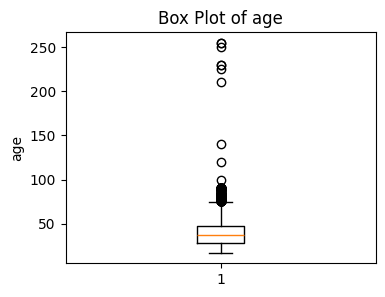

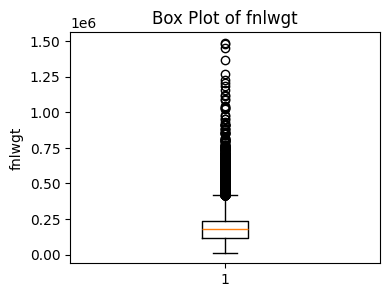

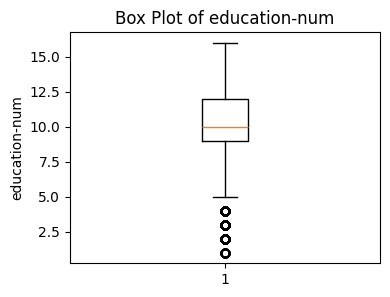

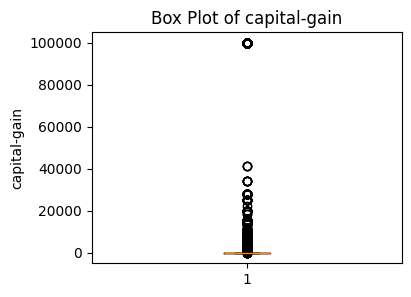

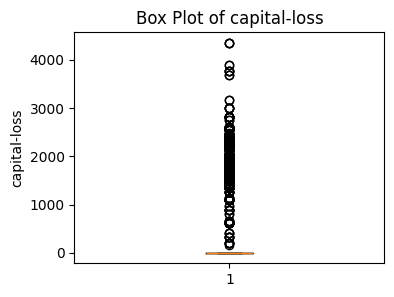

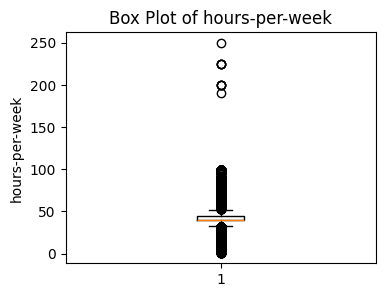

In [17]:
num_cols = adult.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(4, 3))
    plt.boxplot(adult[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


In [18]:
for col in num_cols:
    Q1 = adult[col].quantile(0.25)
    Q3 = adult[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    adult[col] = adult[col].clip(lower, upper)


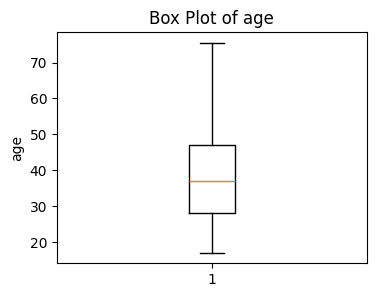

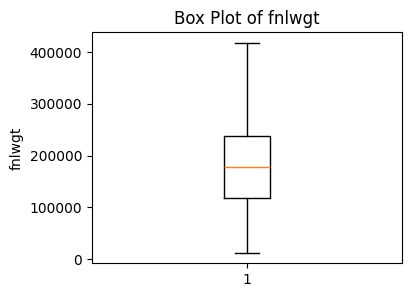

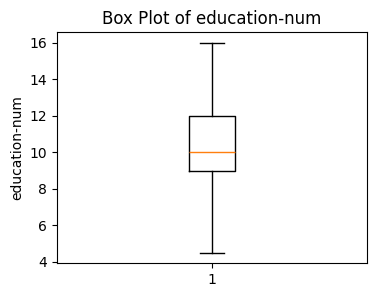

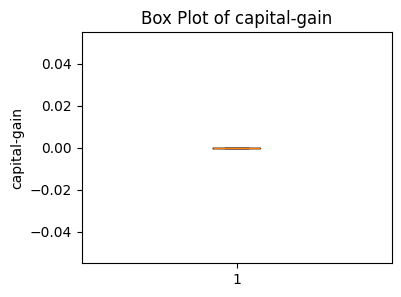

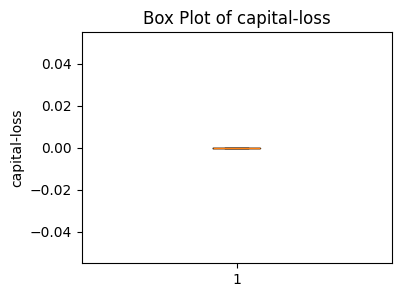

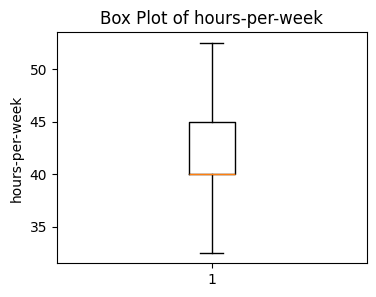

In [19]:
num_cols = adult.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(4, 3))
    plt.boxplot(adult[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


In [20]:
adult = pd.get_dummies(adult, drop_first=True)

In [21]:
scaler = StandardScaler()
adult[num_cols] = scaler.fit_transform(adult[num_cols])
adult[num_cols]

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.035099,-1.146114,1.171352,0.0,0.0,-0.187374
1,0.864033,-1.085318,1.171352,0.0,0.0,-1.430393
2,-0.040259,0.303006,-0.456905,0.0,0.0,-0.187374
3,1.090105,0.503122,-1.271034,0.0,0.0,-0.187374
4,-0.793835,1.590911,1.171352,0.0,0.0,-0.187374
...,...,...,...,...,...,...
48837,0.035099,0.300625,1.171352,0.0,0.0,-0.850318
48838,1.919039,1.412501,-0.456905,0.0,0.0,-0.187374
48839,-0.040259,1.974608,1.171352,0.0,0.0,1.469984
48840,0.411887,-1.079234,1.171352,0.0,0.0,-0.187374


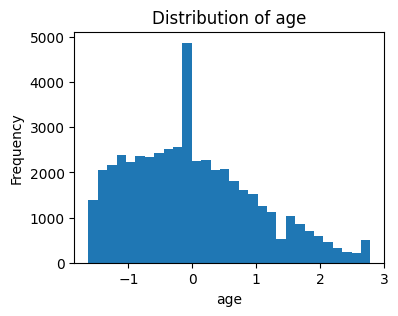

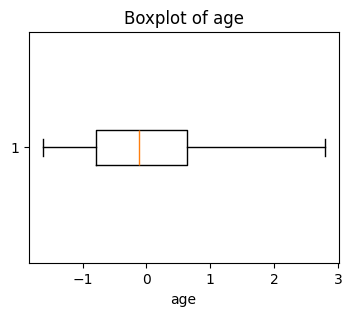

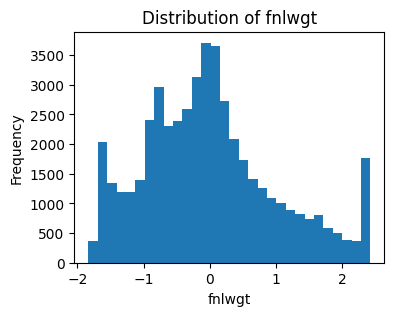

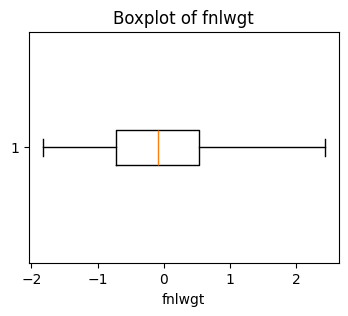

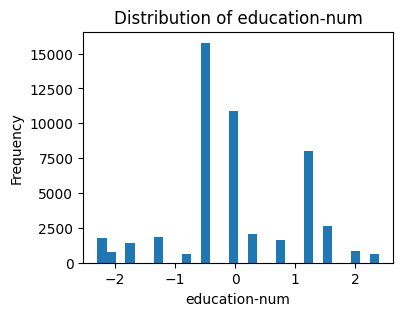

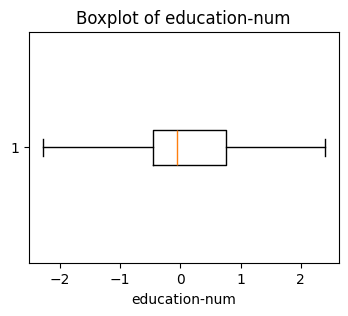

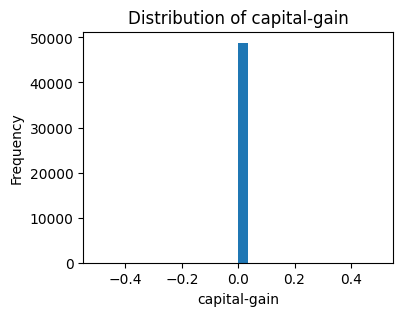

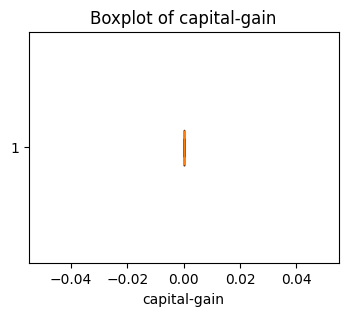

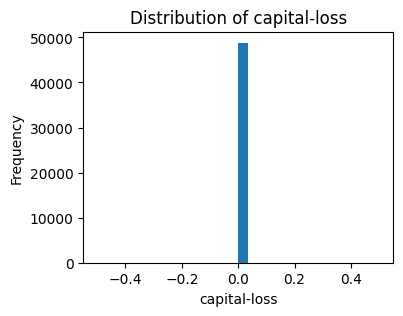

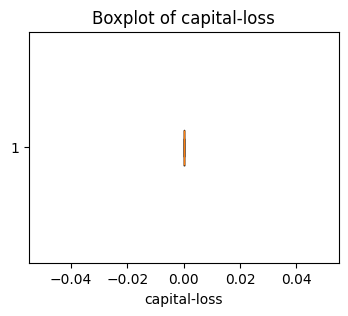

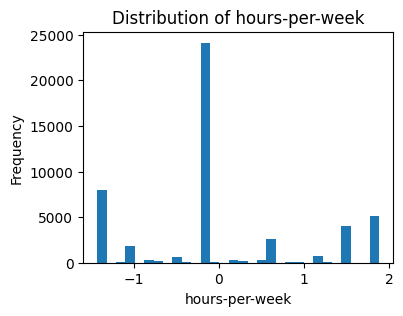

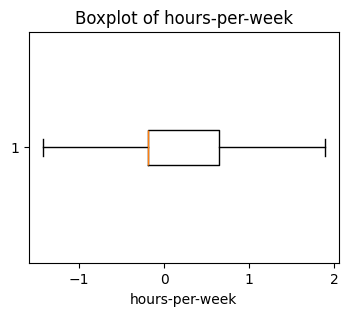

In [22]:
#visualize feature distribution


num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

for col in num_cols:
    # Histogram
    plt.figure(figsize=(4,3))
    plt.hist(adult[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    # Boxplot
    plt.figure(figsize=(4,3))
    plt.boxplot(adult[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

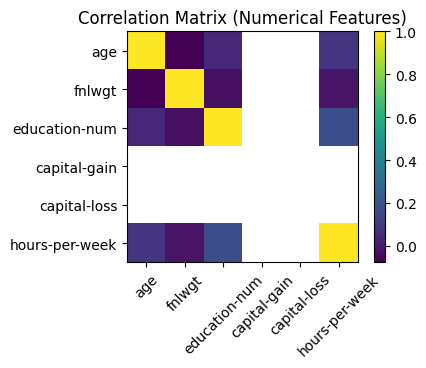

In [23]:
num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

# Compute correlation matrix
corr_matrix = adult[num_cols].corr()

# Plot correlation heatmap using matplotlib
plt.figure(figsize=(4,3))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

In [24]:
scaler = StandardScaler()
adult_scaled = scaler.fit_transform(adult)

Clustering

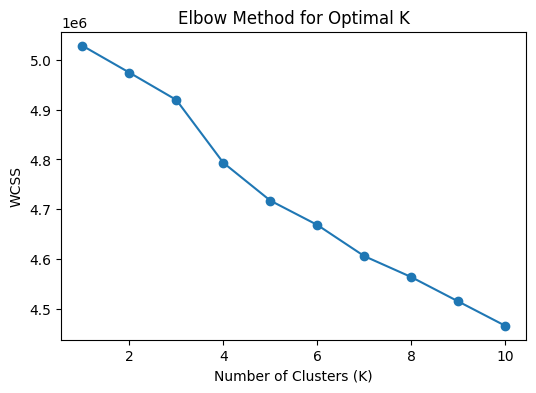

In [25]:
from sklearn.cluster import KMeans

wcss = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(adult_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


In [26]:
scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(adult_scaled)
    score = silhouette_score(adult_scaled, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.3f}")

best_k = max(scores, key=scores.get)
print("silhouette:", best_k)

k=2, silhouette score=0.512
k=3, silhouette score=0.032
k=4, silhouette score=0.047
k=5, silhouette score=0.023
k=6, silhouette score=0.025
k=7, silhouette score=0.030
k=8, silhouette score=0.049
k=9, silhouette score=0.050
k=10, silhouette score=0.050
silhouette: 2


In [27]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
labels = kmeans.fit_predict(adult_scaled)

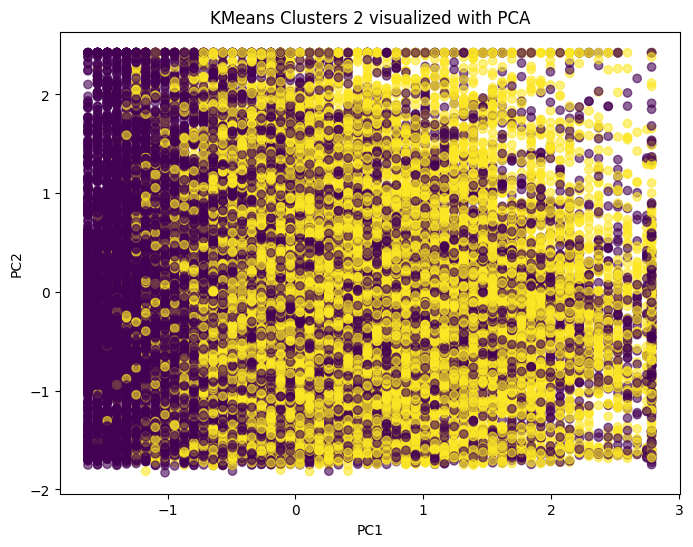

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(adult_scaled[:,0], adult_scaled[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters {best_k} visualized with PCA")
plt.show()